# 06 — NMF representation and clustering

**Notebook 6 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Fit the production nonnegative matrix factorization and derive NMF-Ward and NMF-KMeans assignments at k = 2 and k = 3.

**Primary inputs:** `data/processed/drosophila_features_reduced.csv`

**Primary outputs:** `data/processed/k2_cluster_assignments_nmf.csv`; `data/processed/k3_cluster_assignments_nmf.csv`

**Manuscript role:** NMF representation and clustering; supplies NH and NK streams for the complete six-stream audits and strict consensus analyses.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes the explicit nonnegative 45-feature interface written by Notebook 04 and requires no private, diagnostic, or obsolete provenance artifact.

The production model uses rank 5, `nndsvda` initialization, and fixed random seed 42 on the unscaled 108 × 45 nonnegative feature matrix. Rows of $W$ are the five-dimensional cell representations used for clustering; $H$ supports feature interpretation.

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score,
                             davies_bouldin_score, normalized_mutual_info_score, rand_score,
                             silhouette_score)

RANDOM_STATE = 42
NMF_RANK = 5
INPUT_PATH = Path("data/processed/drosophila_features_reduced.csv")
K2_OUTPUT_PATH = Path("data/processed/k2_cluster_assignments_nmf.csv")
K3_OUTPUT_PATH = Path("data/processed/k3_cluster_assignments_nmf.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Input and integrity validation

The first CSV column is the cell identifier and the remaining columns are the 45 selected production features. Assertions reject duplicate identifiers or feature names, missing/non-finite values, negative values, and an unexpected shape. Values are not rescaled. A value slightly above one because of floating-point representation is permitted because NMF requires nonnegativity rather than an upper bound.

In [2]:
raw = pd.read_csv(INPUT_PATH)
cell_name_col = raw.columns[0]
identifier_missing_count = int(raw.iloc[:, 0].isna().sum())
cell_names = raw.iloc[:, 0].astype(str)
cell_order = cell_names.tolist()
features = raw.iloc[:, 1:].copy()
X = features.to_numpy(dtype=float)

duplicate_feature_count = int(features.columns.duplicated().sum())
nonfinite_count = int((~np.isfinite(X)).sum())
assert raw.shape == (108, 46), f"Expected identifier + 45 features for 108 cells; got {raw.shape}"
assert X.shape == (108, 45)
assert identifier_missing_count == 0, "Cell identifiers must not be missing"
assert cell_names.is_unique and len(cell_order) == 108, "Cell identifiers must be unique"
assert duplicate_feature_count == 0, "Feature column names must be unique"
assert nonfinite_count == 0, "Feature values must all be finite"
assert np.min(X) >= 0, "NMF input must be nonnegative"
assert cell_names.tolist() == cell_order, "Input cell order must remain deterministic"

print(f"Input: {INPUT_PATH}")
print(f"Cell-by-feature shape: {X.shape}")
print(f"Identifier column: {cell_name_col}; identifiers unique: {cell_names.is_unique}; missing: {identifier_missing_count}")
print(f"Duplicate feature columns: {duplicate_feature_count}")
print(f"Non-finite values: {nonfinite_count}")
print(f"Feature range: [{X.min():.16g}, {X.max():.16g}]")

Input: data\processed\drosophila_features_reduced.csv
Cell-by-feature shape: (108, 45)
Identifier column: Unnamed: 0; identifiers unique: True; missing: 0
Duplicate feature columns: 0
Non-finite values: 0
Feature range: [0, 1]


## NMF rank and reconstruction

For each rank from 1 through 10, NMF uses `init="nndsvda"`, `random_state=42`, and at most 3,000 iterations. The reconstruction variance proxy is

$$1 - \frac{\mathrm{SSE}(X-WH)}{\mathrm{SST}(X)}.$$

This variance-style reconstruction summary is not PCA explained variance. Reconstruction improves monotonically over the tested range. Rank five is retained as a parsimonious and interpretable representation, not as a mathematically unique optimum. Higher ranks improve reconstruction, but the sensitivity analysis below shows that they can materially change cluster partitions rather than simply refine the rank-five structure.

,NMF rank,Reconstruction variance proxy (%)
0,1,46.07
1,2,60.02
2,3,69.26
3,4,74.65
4,5,78.17
5,6,81.10
6,7,83.48
7,8,85.41
8,9,87.24
9,10,88.74


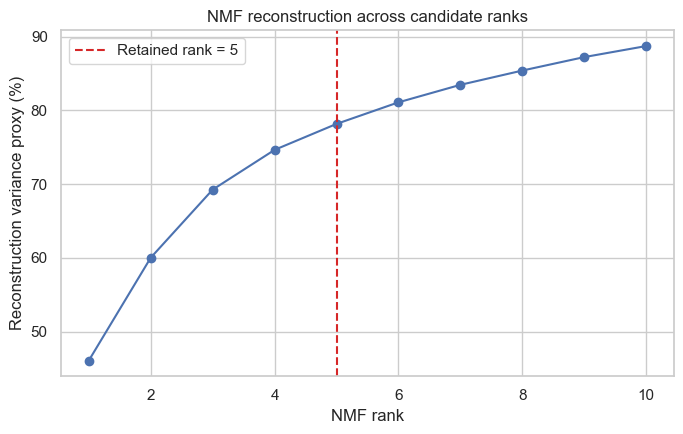

Retained rank: 5; W shape=(108, 5); H shape=(5, 45)
Rank-5 reconstruction variance proxy: 0.781746240840736 (78.1746%)


In [3]:
def fit_nmf(rank):
    model = NMF(n_components=rank, init="nndsvda", max_iter=3000,
                random_state=RANDOM_STATE)
    scores = model.fit_transform(X)
    return model, scores, model.components_

def reconstruction_proxy(scores, loadings):
    sse = np.square(X - scores @ loadings).sum()
    sst = np.square(X - X.mean()).sum()
    return 1 - sse / sst

rank_fits = {rank: fit_nmf(rank) for rank in range(1, 11)}
reconstruction_by_rank = {
    rank: reconstruction_proxy(scores, loadings)
    for rank, (_, scores, loadings) in rank_fits.items()
}
reconstruction_table = pd.DataFrame({
    "NMF rank": list(reconstruction_by_rank),
    "Reconstruction variance proxy": list(reconstruction_by_rank.values()),
})
reconstruction_display = reconstruction_table.copy()
reconstruction_display["Reconstruction variance proxy (%)"] = (
    100 * reconstruction_display.pop("Reconstruction variance proxy")
).round(2)
display(reconstruction_display)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(reconstruction_table["NMF rank"], reconstruction_table["Reconstruction variance proxy"] * 100,
        marker="o")
ax.axvline(NMF_RANK, color="tab:red", linestyle="--", label="Retained rank = 5")
ax.set(xlabel="NMF rank", ylabel="Reconstruction variance proxy (%)",
       title="NMF reconstruction across candidate ranks")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nmf_reconstruction_variance_by_rank.png", dpi=300)
plt.show()

nmf_model, W, H = rank_fits[NMF_RANK]
rank5_reconstruction = reconstruction_by_rank[NMF_RANK]
assert W.shape == (108, 5) and H.shape == (5, 45)
assert np.isfinite(W).all() and np.isfinite(H).all()
assert (W >= 0).all() and (H >= 0).all()
assert np.isclose(rank5_reconstruction, 0.7817462408407356, rtol=0.0, atol=5e-12)
print(f"Retained rank: {NMF_RANK}; W shape={W.shape}; H shape={H.shape}")
print(f"Rank-5 reconstruction variance proxy: {rank5_reconstruction:.15f} ({rank5_reconstruction:.4%})")

## Rank-sensitivity diagnostics

Candidate ranks 4–7 are compared using the $W$ matrix from the same `nndsvda` initialization and fixed seed. The descriptive KMeans elbow marker is computed from the maximum perpendicular distance to the line joining the first and last points of the inertia curve for `k=1...15`; it is not a rank-selection rule. Cluster sizes and Ward/KMeans agreement use the k = 3 finer resolution. Cross-rank RI and NMI assess partition stability for all rank pairs. This is bounded sensitivity analysis around the rank-five production representation, not a new rank-search exercise.

In [4]:
def elbow_marker(scores, max_k=15):
    ks = np.arange(1, max_k + 1)
    inertias = np.array([
        KMeans(n_clusters=int(k), random_state=RANDOM_STATE, n_init="auto")
        .fit(scores).inertia_ for k in ks
    ])
    points = np.column_stack((ks, inertias))
    start, end = points[0], points[-1]
    line = end - start
    offsets = points - start
    distances = np.abs(line[0] * offsets[:, 1] - line[1] * offsets[:, 0]) / np.linalg.norm(line)
    return int(ks[np.argmax(distances)]), ks, inertias

def size_text(labels):
    return " / ".join(str(v) for v in np.bincount(labels)[np.bincount(labels) > 0])

rank_partitions = {}
rank_rows = []
for rank in range(4, 8):
    _, scores, loadings = rank_fits[rank]
    km_labels = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init="auto").fit_predict(scores)
    hc_labels = fcluster(linkage(scores, method="ward"), t=3, criterion="maxclust")
    elbow_k, _, _ = elbow_marker(scores)
    rank_partitions[rank] = {"KMeans": km_labels, "Ward HC": hc_labels}
    rank_rows.append({
        "Rank": rank,
        "Reconstruction variance proxy": reconstruction_by_rank[rank],
        "KMeans elbow marker": elbow_k,
        "KMeans k=3 sizes": size_text(km_labels),
        "Ward HC k=3 sizes": size_text(hc_labels),
        "HC-KMeans RI": rand_score(hc_labels, km_labels),
        "HC-KMeans NMI": normalized_mutual_info_score(hc_labels, km_labels),
    })
rank_sensitivity = pd.DataFrame(rank_rows)
rank_sensitivity_display = rank_sensitivity.copy()
rank_sensitivity_display["Reconstruction variance proxy"] = (
    100 * rank_sensitivity_display["Reconstruction variance proxy"]
).round(2).astype(str) + "%"
display(rank_sensitivity_display.round({"HC-KMeans RI": 4, "HC-KMeans NMI": 4}))
rank5_sensitivity_row = rank_sensitivity.loc[rank_sensitivity["Rank"] == 5].iloc[0]
assert np.isclose(rank5_sensitivity_row["Reconstruction variance proxy"], 0.7817462408407356, rtol=0.0, atol=5e-12)
assert rank5_sensitivity_row["KMeans k=3 sizes"] == "33 / 37 / 38"
assert rank5_sensitivity_row["Ward HC k=3 sizes"] == "39 / 34 / 35"
assert np.isclose(rank5_sensitivity_row["HC-KMeans RI"], 0.8435444790584977, rtol=0.0, atol=5e-12)
assert np.isclose(rank5_sensitivity_row["HC-KMeans NMI"], 0.603170, rtol=0.0, atol=5e-7)

stability_rows = []
for algorithm in ("KMeans", "Ward HC"):
    for rank_a, rank_b in combinations(range(4, 8), 2):
        labels_a = rank_partitions[rank_a][algorithm]
        labels_b = rank_partitions[rank_b][algorithm]
        stability_rows.append({"Algorithm": algorithm, "Rank pair": f"{rank_a} vs {rank_b}",
                               "RI": rand_score(labels_a, labels_b),
                               "NMI": normalized_mutual_info_score(labels_a, labels_b)})
rank_partition_stability = pd.DataFrame(stability_rows)
display(rank_partition_stability.round({"RI": 4, "NMI": 4}))

,Rank,Reconstruction variance proxy,KMeans elbow marker,KMeans k=3 sizes,Ward HC k=3 sizes,HC-KMeans RI,HC-KMeans NMI
0,4,74.65%,4,22 / 47 / 39,19 / 38 / 51,0.9221,0.7961
1,5,78.17%,6,33 / 37 / 38,39 / 34 / 35,0.8435,0.6032
2,6,81.1%,5,18 / 75 / 15,72 / 10 / 26,0.9015,0.6958
3,7,83.48%,7,27 / 36 / 45,33 / 4 / 71,0.6809,0.4386


,Algorithm,Rank pair,RI,NMI
0,KMeans,4 vs 5,0.7629,0.5037
1,KMeans,4 vs 6,0.6127,0.3201
2,KMeans,4 vs 7,0.6116,0.1742
3,KMeans,5 vs 6,0.6192,0.3380
4,KMeans,5 vs 7,0.7328,0.3834
5,KMeans,6 vs 7,0.5981,0.2360
6,Ward HC,4 vs 5,0.7615,0.5674
7,Ward HC,4 vs 6,0.6149,0.3417
8,Ward HC,4 vs 7,0.4953,0.1107
9,Ward HC,5 vs 6,0.6336,0.3689


The reconstruction gain from rank five to rank six is about 2.9 percentage points, but the cross-rank results demonstrate that the clustering changes materially. Five components are therefore retained as an interpretability/parsimony compromise; neither reconstruction alone nor HC–KMeans agreement makes rank five uniquely optimal.

## Cluster-number sensitivity at fixed rank five

The fixed rank-five $W$ representation is evaluated over k=2,...,7 without choosing k from one statistic alone. The diagnostics do not identify a single universally optimal cluster number. However, k=2 provides a particularly coherent coarse NMF partition: it has the highest silhouette and Calinski–Harabasz scores and the strongest Ward/KMeans RI and NMI over the tested range. Davies–Bouldin alone favors k=3. Accordingly, k=2 is retained as the primary coarse resolution, while the established k=3 assignments remain the secondary finer-resolution analysis.

,k,KMeans inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,KMeans sizes,Ward HC sizes,HC-KMeans RI,HC-KMeans NMI
0,2,9.434,0.3246,51.02,1.291,36 / 72,39 / 69,0.9109,0.7264
1,3,7.412,0.2627,46.49,1.168,33 / 37 / 38,39 / 34 / 35,0.8435,0.6032
2,4,6.205,0.2599,43.41,1.279,14 / 35 / 32 / 27,5 / 34 / 34 / 35,0.8041,0.5376
3,5,5.377,0.2489,41.18,1.250,11 / 22 / 29 / 22 / 24,5 / 17 / 17 / 34 / 35,0.8212,0.6021
4,6,4.525,0.2457,42.61,1.219,16 / 21 / 21 / 22 / 23 / 5,5 / 17 / 17 / 34 / 22 / 13,0.8152,0.5597
5,7,4.237,0.2201,38.68,1.209,16 / 24 / 13 / 19 / 7 / 5 / 24,5 / 17 / 17 / 15 / 19 / 22 / 13,0.8493,0.6076


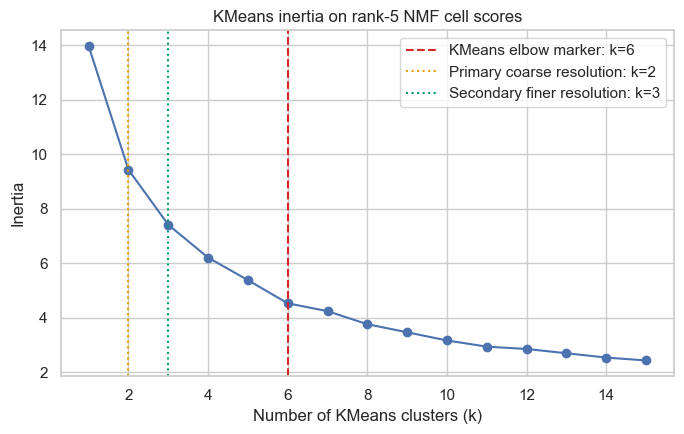

Inertia elbow diagnostic marker: k=6
Cluster-number diagnostic winners: {'Silhouette': 2, 'Calinski-Harabasz': 2, 'Davies-Bouldin': 3, 'HC-KMeans RI': 2, 'HC-KMeans NMI': 2}


In [5]:
Z_rank5 = linkage(W, method="ward")
cluster_rows = []
inertias = []
for k in range(2, 8):
    km_model_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km_labels_k = km_model_k.fit_predict(W)
    hc_labels_k = fcluster(Z_rank5, t=k, criterion="maxclust")
    inertia = km_model_k.inertia_
    inertias.append(inertia)
    cluster_rows.append({
        "k": k, "KMeans inertia": inertia,
        "Silhouette": silhouette_score(W, km_labels_k),
        "Calinski-Harabasz": calinski_harabasz_score(W, km_labels_k),
        "Davies-Bouldin": davies_bouldin_score(W, km_labels_k),
        "KMeans sizes": size_text(km_labels_k), "Ward HC sizes": size_text(hc_labels_k),
        "HC-KMeans RI": rand_score(hc_labels_k, km_labels_k),
        "HC-KMeans NMI": normalized_mutual_info_score(hc_labels_k, km_labels_k),
    })
cluster_number_sensitivity = pd.DataFrame(cluster_rows)
k2_sensitivity = cluster_number_sensitivity.loc[cluster_number_sensitivity["k"] == 2].iloc[0]
k3_sensitivity = cluster_number_sensitivity.loc[cluster_number_sensitivity["k"] == 3].iloc[0]
for observed, expected in [
    (k2_sensitivity["KMeans inertia"], 9.433994),
    (k2_sensitivity["Silhouette"], 0.324573),
    (k2_sensitivity["Calinski-Harabasz"], 51.022789),
    (k2_sensitivity["Davies-Bouldin"], 1.290873),
    (k2_sensitivity["HC-KMeans RI"], 0.910869),
    (k2_sensitivity["HC-KMeans NMI"], 0.726354),
    (k3_sensitivity["KMeans inertia"], 7.411560),
    (k3_sensitivity["Silhouette"], 0.262653),
    (k3_sensitivity["Calinski-Harabasz"], 46.492459),
    (k3_sensitivity["Davies-Bouldin"], 1.168066),
    (k3_sensitivity["HC-KMeans RI"], 0.843544),
    (k3_sensitivity["HC-KMeans NMI"], 0.603170),
]:
    assert np.isclose(observed, expected, rtol=0.0, atol=5e-7)
sensitivity_winners = {
    "Silhouette": int(cluster_number_sensitivity.loc[cluster_number_sensitivity["Silhouette"].idxmax(), "k"]),
    "Calinski-Harabasz": int(cluster_number_sensitivity.loc[cluster_number_sensitivity["Calinski-Harabasz"].idxmax(), "k"]),
    "Davies-Bouldin": int(cluster_number_sensitivity.loc[cluster_number_sensitivity["Davies-Bouldin"].idxmin(), "k"]),
    "HC-KMeans RI": int(cluster_number_sensitivity.loc[cluster_number_sensitivity["HC-KMeans RI"].idxmax(), "k"]),
    "HC-KMeans NMI": int(cluster_number_sensitivity.loc[cluster_number_sensitivity["HC-KMeans NMI"].idxmax(), "k"]),
}
assert sensitivity_winners == {
    "Silhouette": 2, "Calinski-Harabasz": 2, "Davies-Bouldin": 3,
    "HC-KMeans RI": 2, "HC-KMeans NMI": 2,
}
display(cluster_number_sensitivity.round({
    "KMeans inertia": 3, "Silhouette": 4,
    "Calinski-Harabasz": 2, "Davies-Bouldin": 3,
    "HC-KMeans RI": 4, "HC-KMeans NMI": 4}))

elbow_k, elbow_ks, elbow_inertias = elbow_marker(W)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(elbow_ks, elbow_inertias, marker="o")
ax.axvline(elbow_k, color="tab:red", linestyle="--", label=f"KMeans elbow marker: k={elbow_k}")
ax.axvline(2, color="#E69F00", linestyle=":", label="Primary coarse resolution: k=2")
ax.axvline(3, color="#009E73", linestyle=":", label="Secondary finer resolution: k=3")
ax.set(xlabel="Number of KMeans clusters (k)", ylabel="Inertia",
       title="KMeans inertia on rank-5 NMF cell scores")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nmf_rank5_kmeans_inertia.png", dpi=300)
plt.show()
print(f"Inertia elbow diagnostic marker: k={elbow_k}")
print(f"Cluster-number diagnostic winners: {sensitivity_winners}")

## Primary k=2 and secondary k=3 production clustering

The authoritative clustering input is the full five-dimensional $W$ matrix: rows are cells and columns are component scores. One Ward hierarchy (`Z_rank5`) supplies both native one-based cuts. KMeans uses its native labels, normalized for production only by adding one; labels are never permuted for cross-method agreement. The paired score panels below project onto Components 1 and 2 for visualization only. The $H$ matrix is retained for component-by-feature interpretation.

Primary k=2 NH versus NK contingency:


K2_NK,1,2
K2_NH,,
1,35,4
2,1,68


K2_NH counts: {1: 39, 2: 69}
K2_NK raw counts: {0: 36, 1: 72}; exported counts: {1: 36, 2: 72}
K2 NH vs NK: RI=0.910868812737972; NMI=0.726354343725213; ARI=0.820472723126293
K3_NH counts: {1: 39, 2: 34, 3: 35}
K3_NK raw counts: {0: 33, 1: 37, 2: 38}; exported counts: {1: 33, 2: 37, 3: 38}
K3 NH vs NK: RI=0.843544479058498; NMI=0.603170072803162


,Component,Rank,Feature,Weight
0,1,1,d_poly_mag_c1,2.7827
1,1,2,d_final_magnitude,2.7436
2,1,3,d_poly_peak_c3,2.6427
3,1,4,d_poly_mag_c3,2.5474
4,1,5,d_poly_trough_c0,2.5214
5,2,1,d_initial_peak_to_trough_magnitude,1.3232
6,2,2,d_poly_peak_c0,1.2300
7,2,3,d_initial_magnitude,1.1402
8,2,4,f_early_std,1.1060
9,2,5,d_poly_mag_c0,1.0487


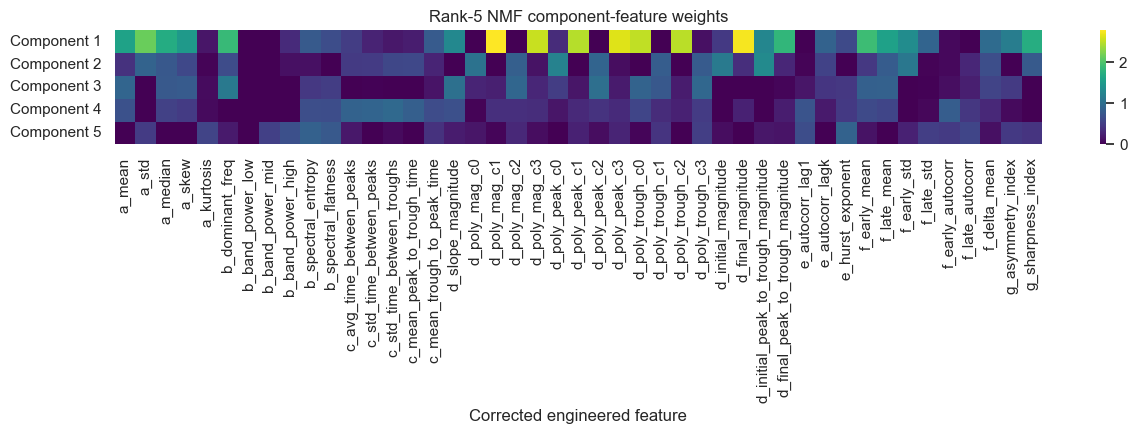

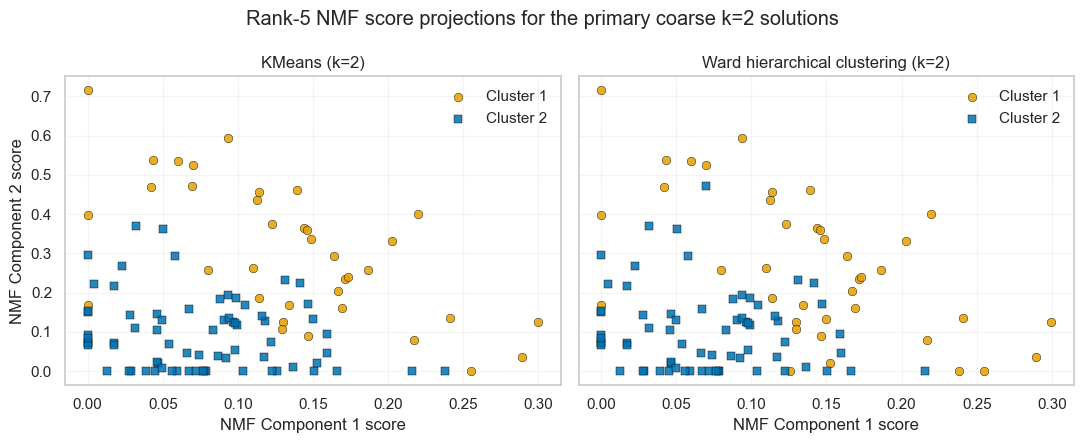

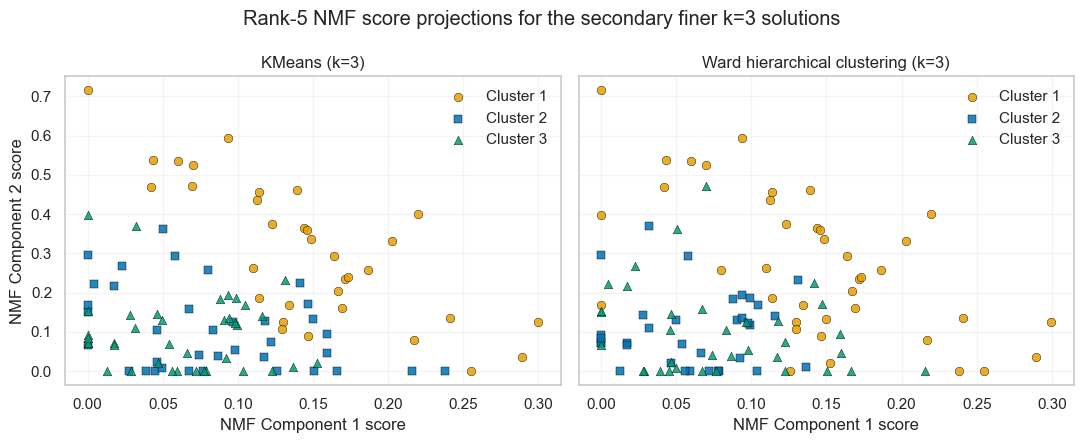

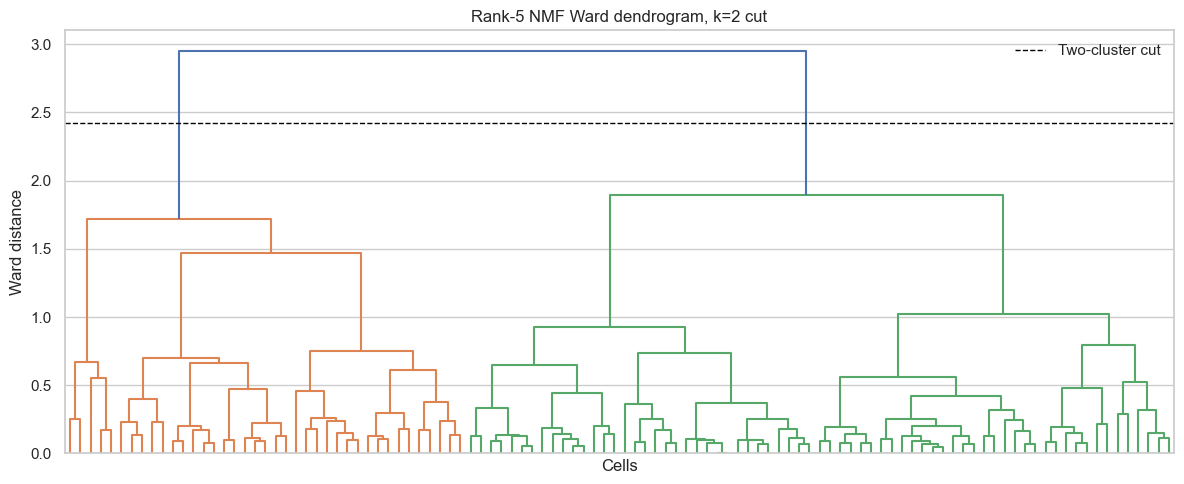

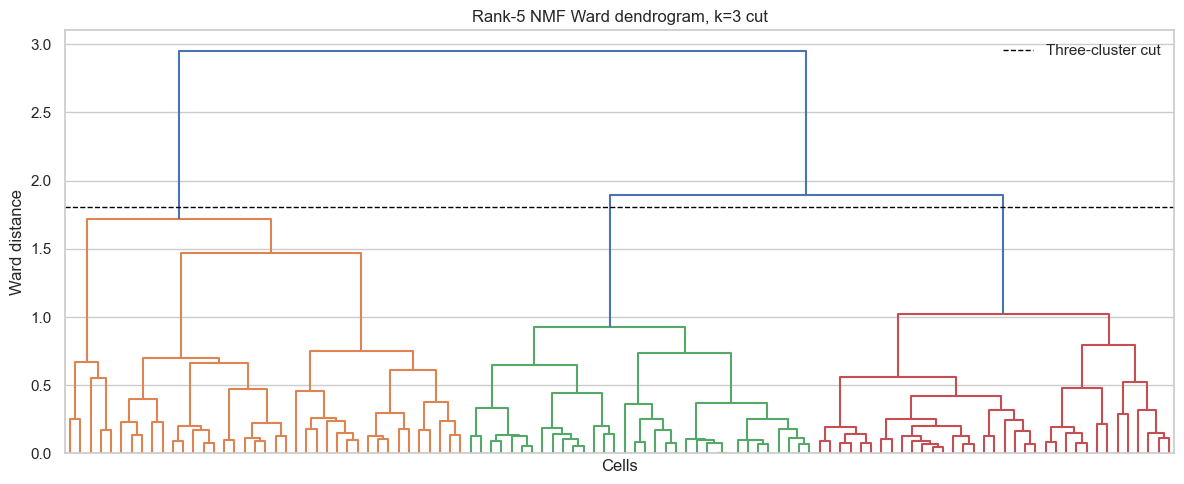

Visual Ward cut heights: k=2 2.422167797952; k=3 1.803053234399
Distance-cut parity with production Ward labels: k=2 ARI=1.0; k=3 ARI=1.0


In [6]:
# One rank-5 Ward hierarchy supplies native one-based k=2 and k=3 cuts.
K2_NH = fcluster(Z_rank5, t=2, criterion="maxclust").astype(int)
K3_NH = fcluster(Z_rank5, t=3, criterion="maxclust").astype(int)

kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init="auto")
K2_NK_raw = kmeans_k2.fit_predict(W)
K2_NK = K2_NK_raw + 1
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
K3_NK_raw = kmeans_k3.fit_predict(W)
K3_NK = K3_NK_raw + 1

assert {label: int(np.sum(K2_NH == label)) for label in (1, 2)} == {1: 39, 2: 69}
assert {label: int(np.sum(K2_NK_raw == label)) for label in (0, 1)} == {0: 36, 1: 72}
assert {label: int(np.sum(K2_NK == label)) for label in (1, 2)} == {1: 36, 2: 72}
assert {label: int(np.sum(K3_NH == label)) for label in (1, 2, 3)} == {1: 39, 2: 34, 3: 35}
assert {label: int(np.sum(K3_NK_raw == label)) for label in (0, 1, 2)} == {0: 33, 1: 37, 2: 38}
assert {label: int(np.sum(K3_NK == label)) for label in (1, 2, 3)} == {1: 33, 2: 37, 3: 38}

k2_contingency = pd.crosstab(
    pd.Series(K2_NH, name="K2_NH"), pd.Series(K2_NK, name="K2_NK")
).reindex(index=[1, 2], columns=[1, 2], fill_value=0)
assert np.array_equal(k2_contingency.to_numpy(), np.asarray([[35, 4], [1, 68]]))
k2_ri = rand_score(K2_NH, K2_NK)
k2_nmi = normalized_mutual_info_score(K2_NH, K2_NK)
k2_ari = adjusted_rand_score(K2_NH, K2_NK)
assert np.isclose(k2_ri, 0.9108688127379716, rtol=0.0, atol=5e-12)
assert np.isclose(k2_nmi, 0.7263543437252130, rtol=0.0, atol=5e-12)
assert np.isclose(k2_ari, 0.8204727231262929, rtol=0.0, atol=5e-12)

k3_contingency = pd.crosstab(
    pd.Series(K3_NH, name="K3_NH"), pd.Series(K3_NK, name="K3_NK")
)
k3_ri = rand_score(K3_NH, K3_NK)
k3_nmi = normalized_mutual_info_score(K3_NH, K3_NK)
assert np.isclose(k3_ri, 0.8435444790584977, rtol=0.0, atol=5e-12)
assert np.isclose(k3_nmi, 0.603170, rtol=0.0, atol=5e-7)

print("Primary k=2 NH versus NK contingency:")
display(k2_contingency)
print(f"K2_NH counts: {{1: 39, 2: 69}}")
print(f"K2_NK raw counts: {{0: 36, 1: 72}}; exported counts: {{1: 36, 2: 72}}")
print(f"K2 NH vs NK: RI={k2_ri:.15f}; NMI={k2_nmi:.15f}; ARI={k2_ari:.15f}")
print(f"K3_NH counts: {{1: 39, 2: 34, 3: 35}}")
print(f"K3_NK raw counts: {{0: 33, 1: 37, 2: 38}}; exported counts: {{1: 33, 2: 37, 3: 38}}")
print(f"K3 NH vs NK: RI={k3_ri:.15f}; NMI={k3_nmi:.15f}")

top_rows = []
for component_index, weights in enumerate(H, start=1):
    for rank_position, feature_index in enumerate(np.argsort(weights)[::-1][:5], start=1):
        top_rows.append({"Component": component_index, "Rank": rank_position,
                         "Feature": features.columns[feature_index],
                         "Weight": weights[feature_index]})
top_features = pd.DataFrame(top_rows)
display(top_features.round({"Weight": 4}))

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(pd.DataFrame(H, index=[f"Component {i}" for i in range(1, 6)],
                         columns=features.columns), cmap="viridis", ax=ax)
ax.set(title="Rank-5 NMF component-feature weights", xlabel="Corrected engineered feature", ylabel="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nmf_rank5_component_feature_heatmap.png", dpi=300)
plt.show()

cluster_color_map = {1: "#E69F00", 2: "#0072B2", 3: "#009E73"}
cluster_marker_map = {1: "o", 2: "s", 3: "^"}

def plot_score_pair(left_labels, right_labels, left_title, right_title, suptitle, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
    for ax, labels, title in [(axes[0], left_labels, left_title), (axes[1], right_labels, right_title)]:
        for label in np.unique(labels):
            mask = labels == label
            ax.scatter(W[mask, 0], W[mask, 1], s=38, alpha=0.85,
                       color=cluster_color_map[int(label)], marker=cluster_marker_map[int(label)],
                       edgecolor="black", linewidth=0.35, label=f"Cluster {label}")
        ax.set(title=title, xlabel="NMF Component 1 score")
        ax.grid(alpha=0.2)
        ax.legend(frameon=False)
    axes[0].set_ylabel("NMF Component 2 score")
    fig.suptitle(suptitle)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_score_pair(
    K2_NK, K2_NH, "KMeans (k=2)", "Ward hierarchical clustering (k=2)",
    "Rank-5 NMF score projections for the primary coarse k=2 solutions",
    FIGURE_DIR / "nmf_rank5_hc2_vs_km2_scores.png",
)
plot_score_pair(
    K3_NK, K3_NH, "KMeans (k=3)", "Ward hierarchical clustering (k=3)",
    "Rank-5 NMF score projections for the secondary finer k=3 solutions",
    FIGURE_DIR / "nmf_rank5_hc3_vs_km3_scores.png",
)

k2_cut_height = (Z_rank5[-2, 2] + Z_rank5[-1, 2]) / 2
k3_cut_height = (Z_rank5[-3, 2] + Z_rank5[-2, 2]) / 2
k2_distance_cut = fcluster(Z_rank5, t=k2_cut_height, criterion="distance")
k3_distance_cut = fcluster(Z_rank5, t=k3_cut_height, criterion="distance")
k2_cut_ari = adjusted_rand_score(K2_NH, k2_distance_cut)
k3_cut_ari = adjusted_rand_score(K3_NH, k3_distance_cut)
assert np.isclose(k2_cut_ari, 1.0, rtol=0.0, atol=1e-12)
assert np.isclose(k3_cut_ari, 1.0, rtol=0.0, atol=1e-12)

def plot_ward_dendrogram(cut_height, cut_label, title, output_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    dendrogram(Z_rank5, no_labels=True, color_threshold=cut_height, ax=ax)
    ax.axhline(cut_height, color="black", linestyle="--", linewidth=1, label=cut_label)
    ax.set(title=title, xlabel="Cells", ylabel="Ward distance")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_ward_dendrogram(
    k2_cut_height, "Two-cluster cut", "Rank-5 NMF Ward dendrogram, k=2 cut",
    FIGURE_DIR / "nmf_rank5_ward_hc2_dendrogram.png",
)
plot_ward_dendrogram(
    k3_cut_height, "Three-cluster cut", "Rank-5 NMF Ward dendrogram, k=3 cut",
    FIGURE_DIR / "nmf_rank5_ward_hc3_dendrogram.png",
)
print(f"Visual Ward cut heights: k=2 {k2_cut_height:.12f}; k=3 {k3_cut_height:.12f}")
print(f"Distance-cut parity with production Ward labels: k=2 ARI={k2_cut_ari:.1f}; k=3 ARI={k3_cut_ari:.1f}")

## Explicit production assignments and final validation

Resolution-specific exports preserve deterministic input order and pipeline-local one-based labels. The legacy `data/processed/3_cluster_assignments_nmf.csv` is not regenerated and is not consumed by Notebook 07 or any other production notebook. The closing validation reports the rank-five representation, both production resolutions, explicit outputs, and notebook diagnostic figures.

In [7]:
k2_assignments = pd.DataFrame({
    "Cell_Name": cell_order,
    "K2_NH": K2_NH,
    "K2_NK": K2_NK,
})
k3_assignments = pd.DataFrame({
    "Cell_Name": cell_order,
    "K3_NH": K3_NH,
    "K3_NK": K3_NK,
})

assert k2_assignments.shape == (108, 3)
assert k2_assignments.columns.tolist() == ["Cell_Name", "K2_NH", "K2_NK"]
assert k2_assignments["Cell_Name"].tolist() == cell_order
assert k2_assignments["Cell_Name"].is_unique and not k2_assignments.isna().any().any()
assert all(pd.api.types.is_integer_dtype(k2_assignments[column]) for column in ["K2_NH", "K2_NK"])
assert set(k2_assignments["K2_NH"]) == {1, 2}
assert set(k2_assignments["K2_NK"]) == {1, 2}
assert k2_assignments["K2_NH"].value_counts().sort_index().to_dict() == {1: 39, 2: 69}
assert k2_assignments["K2_NK"].value_counts().sort_index().to_dict() == {1: 36, 2: 72}

assert k3_assignments.shape == (108, 3)
assert k3_assignments.columns.tolist() == ["Cell_Name", "K3_NH", "K3_NK"]
assert k3_assignments["Cell_Name"].tolist() == cell_order
assert k3_assignments["Cell_Name"].is_unique and not k3_assignments.isna().any().any()
assert all(pd.api.types.is_integer_dtype(k3_assignments[column]) for column in ["K3_NH", "K3_NK"])
assert set(k3_assignments["K3_NH"]) == {1, 2, 3}
assert set(k3_assignments["K3_NK"]) == {1, 2, 3}
assert k3_assignments["K3_NH"].value_counts().sort_index().to_dict() == {1: 39, 2: 34, 3: 35}
assert k3_assignments["K3_NK"].value_counts().sort_index().to_dict() == {1: 33, 2: 37, 3: 38}

K2_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
k2_assignments.to_csv(K2_OUTPUT_PATH, index=False)
k3_assignments.to_csv(K3_OUTPUT_PATH, index=False)

figure_paths = [
    FIGURE_DIR / "nmf_reconstruction_variance_by_rank.png",
    FIGURE_DIR / "nmf_rank5_kmeans_inertia.png",
    FIGURE_DIR / "nmf_rank5_component_feature_heatmap.png",
    FIGURE_DIR / "nmf_rank5_hc2_vs_km2_scores.png",
    FIGURE_DIR / "nmf_rank5_hc3_vs_km3_scores.png",
    FIGURE_DIR / "nmf_rank5_ward_hc2_dendrogram.png",
    FIGURE_DIR / "nmf_rank5_ward_hc3_dendrogram.png",
]
assert all(path.exists() and path.stat().st_size > 0 for path in figure_paths)

validation_summary = pd.Series({
    "Input path": str(INPUT_PATH),
    "Input shape": X.shape,
    "Unique Cell_Name": len(set(cell_order)),
    "Duplicate feature columns": duplicate_feature_count,
    "Non-finite values": nonfinite_count,
    "Nonnegative input": bool(X.min() >= 0),
    "NMF rank": NMF_RANK,
    "W shape": W.shape,
    "H shape": H.shape,
    "Reconstruction variance proxy": f"{rank5_reconstruction:.15f}",
    "Cluster-number diagnostic winners": sensitivity_winners,
    "K2_NH counts": k2_assignments["K2_NH"].value_counts().sort_index().to_dict(),
    "K2_NK counts": k2_assignments["K2_NK"].value_counts().sort_index().to_dict(),
    "k2 RI/NMI/ARI": f"{k2_ri:.15f} / {k2_nmi:.15f} / {k2_ari:.15f}",
    "K3_NH counts": k3_assignments["K3_NH"].value_counts().sort_index().to_dict(),
    "K3_NK counts": k3_assignments["K3_NK"].value_counts().sort_index().to_dict(),
    "k3 RI/NMI": f"{k3_ri:.15f} / {k3_nmi:.15f}",
    "k2 export": f"{K2_OUTPUT_PATH} | {k2_assignments.shape} | {k2_assignments.columns.tolist()}",
    "k3 export": f"{K3_OUTPUT_PATH} | {k3_assignments.shape} | {k3_assignments.columns.tolist()}",
}, name="Value")
print("FINAL PRODUCTION VALIDATION")
display(validation_summary.to_frame())
print("Primary k=2 NH versus NK contingency:")
display(k2_contingency)
print("Rank sensitivity:")
display(rank_sensitivity)
print("Cross-rank partition stability:")
display(rank_partition_stability)
print("Cluster-number sensitivity:")
display(cluster_number_sensitivity)
print("Figures generated:")
for path in figure_paths:
    print(f"    - {path}")
print("Legacy data/processed/3_cluster_assignments_nmf.csv was not regenerated.")
print("No Section6_FigY or Book_Chapter_Fig NMF file was written.")

FINAL PRODUCTION VALIDATION


,Value
Input path,data\processed\drosophila_features_reduced.csv
Input shape,"(108, 45)"
Unique Cell_Name,108
Duplicate feature columns,0
Non-finite values,0
Nonnegative input,True
NMF rank,5
W shape,"(108, 5)"
H shape,"(5, 45)"
Reconstruction variance proxy,0.781746240840736


Primary k=2 NH versus NK contingency:


K2_NK,1,2
K2_NH,,
1,35,4
2,1,68


Rank sensitivity:


...

Cross-rank partition stability:


,Algorithm,Rank pair,RI,NMI
0,KMeans,4 vs 5,0.762894,0.503713
1,KMeans,4 vs 6,0.612669,0.320099
2,KMeans,4 vs 7,0.611630,0.174175
3,KMeans,5 vs 6,0.619245,0.338010
4,KMeans,5 vs 7,0.732780,0.383357
5,KMeans,6 vs 7,0.598131,0.236024
6,Ward HC,4 vs 5,0.761509,0.567391
7,Ward HC,4 vs 6,0.614919,0.341714
8,Ward HC,4 vs 7,0.495327,0.110703
9,Ward HC,5 vs 6,0.633610,0.368915


Cluster-number sensitivity:


,k,KMeans inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,KMeans sizes,Ward HC sizes,HC-KMeans RI,HC-KMeans NMI
0,2,9.433994,0.324573,51.022789,1.290873,36 / 72,39 / 69,0.910869,0.726354
1,3,7.411560,0.262653,46.492459,1.168066,33 / 37 / 38,39 / 34 / 35,0.843544,0.603170
2,4,6.204981,0.259917,43.410503,1.278903,14 / 35 / 32 / 27,5 / 34 / 34 / 35,0.804084,0.537641
3,5,5.376564,0.248893,41.180617,1.250131,11 / 22 / 29 / 22 / 24,5 / 17 / 17 / 34 / 35,0.821218,0.602078
4,6,4.524750,0.245650,42.606886,1.218820,16 / 21 / 21 / 22 / 23 / 5,5 / 17 / 17 / 34 / 22 / 13,0.815161,0.559657
5,7,4.237270,0.220141,38.684994,1.208905,16 / 24 / 13 / 19 / 7 / 5 / 24,5 / 17 / 17 / 15 / 19 / 22 / 13,0.849256,0.607602


Figures generated:
    - figures\nmf_reconstruction_variance_by_rank.png
    - figures\nmf_rank5_kmeans_inertia.png
    - figures\nmf_rank5_component_feature_heatmap.png
    - figures\nmf_rank5_hc2_vs_km2_scores.png
    - figures\nmf_rank5_hc3_vs_km3_scores.png
    - figures\nmf_rank5_ward_hc2_dendrogram.png
    - figures\nmf_rank5_ward_hc3_dendrogram.png
Legacy data/processed/3_cluster_assignments_nmf.csv was not regenerated.
No Section6_FigY or Book_Chapter_Fig NMF file was written.


## Conclusion

Rank-five NMF is the compact production representation, with an approximately 78.2% reconstruction variance proxy. At fixed rank five, k = 2 supplies the strongest coarse NMF partition across most retained diagnostics and the strongest Ward/KMeans agreement over k = 2,...,7, while Davies–Bouldin favors k = 3. The primary k = 2 and secondary k = 3 outputs serve different analytical resolutions; neither is presented as a unique optimum or biological ground truth.

## NMF score displays for primary k=2 and secondary k=3

### Notebook-only visualization; not a manuscript figure

Cells are projected onto NMF Components 1 and 2 for display only; clustering uses the complete five-dimensional $W$ representation. The top row shows the primary coarse k=2 KMeans and Ward assignments, and the bottom row shows the secondary finer k=3 assignments. Colors encode local one-based labels only; matching colors across panels do not assert cluster equivalence across algorithms or methods.

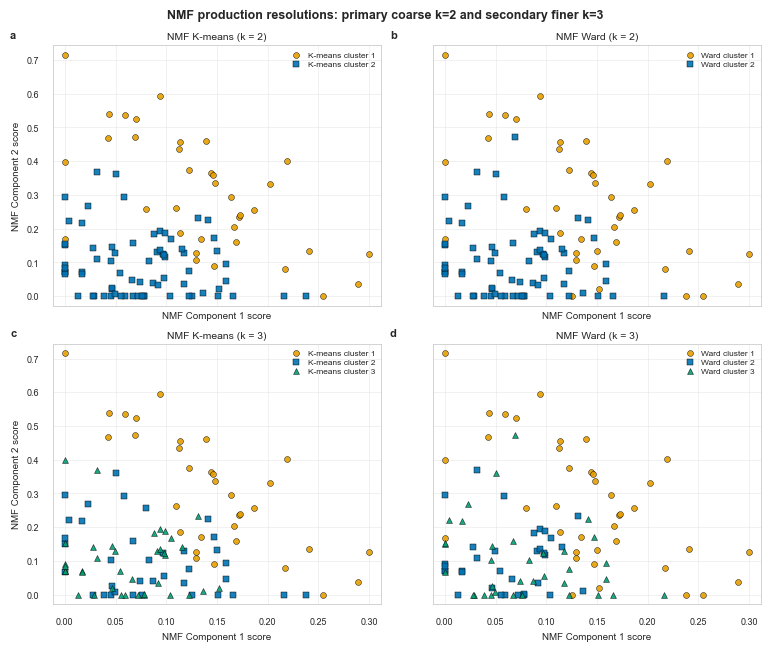

Displayed primary k=2 and secondary k=3 NMF projections; no manuscript figure was written.


In [8]:
# Balanced notebook-only display of both accepted resolutions; no model is refit.
figure_width_in = 7.6
figure_height_in = 6.4
plot_coordinates = np.asarray(W[:, :2])
assert plot_coordinates.shape == (108, 2)
assert np.array_equal(plot_coordinates, W[:, :2])
assert len(K2_NK) == len(K2_NH) == len(K3_NK) == len(K3_NH) == 108
assert np.unique(K2_NK).size == np.unique(K2_NH).size == 2
assert np.unique(K3_NK).size == np.unique(K3_NH).size == 3
assert NMF_RANK == 5

x_pad = 0.04 * np.ptp(plot_coordinates[:, 0])
y_pad = 0.04 * np.ptp(plot_coordinates[:, 1])
shared_xlim = (plot_coordinates[:, 0].min() - x_pad, plot_coordinates[:, 0].max() + x_pad)
shared_ylim = (plot_coordinates[:, 1].min() - y_pad, plot_coordinates[:, 1].max() + y_pad)
publication_rc = {
    "font.size": 7, "axes.titlesize": 7.5, "axes.labelsize": 7,
    "xtick.labelsize": 6.5, "ytick.labelsize": 6.5, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "figure.facecolor": "white",
    "axes.facecolor": "white", "savefig.facecolor": "white",
}
with plt.rc_context(publication_rc):
    fig, axes = plt.subplots(2, 2, figsize=(figure_width_in, figure_height_in),
                             sharex=True, sharey=True, constrained_layout=True)
    panel_specs = [
        (axes[0, 0], K2_NK, "NMF K-means (k = 2)", "K-means cluster", "a"),
        (axes[0, 1], K2_NH, "NMF Ward (k = 2)", "Ward cluster", "b"),
        (axes[1, 0], K3_NK, "NMF K-means (k = 3)", "K-means cluster", "c"),
        (axes[1, 1], K3_NH, "NMF Ward (k = 3)", "Ward cluster", "d"),
    ]
    for ax, labels, title, legend_prefix, panel_label in panel_specs:
        for label in np.unique(labels):
            mask = labels == label
            ax.scatter(plot_coordinates[mask, 0], plot_coordinates[mask, 1], s=18, alpha=0.9,
                       color=cluster_color_map[int(label)], marker=cluster_marker_map[int(label)],
                       edgecolor="black", linewidth=0.35, label=f"{legend_prefix} {label}")
        ax.set_title(title, pad=4)
        ax.set_xlabel("NMF Component 1 score")
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)
        ax.grid(True, color="0.88", alpha=0.8)
        ax.set_axisbelow(True)
        ax.legend(frameon=False, handletextpad=0.35, labelspacing=0.25, borderaxespad=0.3)
        ax.text(-0.13, 1.02, panel_label, transform=ax.transAxes, fontsize=8,
                fontweight="bold", va="bottom", ha="left")
    axes[0, 0].set_ylabel("NMF Component 2 score")
    axes[1, 0].set_ylabel("NMF Component 2 score")
    fig.suptitle("NMF production resolutions: primary coarse k=2 and secondary finer k=3",
                 fontsize=9, fontweight="bold")
    plt.show()

print("Displayed primary k=2 and secondary k=3 NMF projections; no manuscript figure was written.")